In [19]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np

In [20]:
DEVICE = 'mps' if torch.backends.mps.is_available() else 'cpu'

## 2.Loading Dataset

In [21]:
import pandas as pd
from torch.utils.data import Dataset
from PIL import Image
import os

# Custom dataset class for CIFAR-10 format
class CIFAR10Custom(Dataset):
    def __init__(self, img_dir, labels_file, transform=None):
        self.img_dir = img_dir
        self.transform = transform
        self.labels_df = pd.read_csv(labels_file)
        
        # Map class names to indices
        self.class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer',
                            'dog', 'frog', 'horse', 'ship', 'truck']
        self.class_to_idx = {name: idx for idx, name in enumerate(self.class_names)}
    
    def __len__(self):
        return len(self.labels_df)
    
    def __getitem__(self, idx):
        row = self.labels_df.iloc[idx]
        img_id = row['id']
        label_name = row['label']
        
        # Load image
        img_path = os.path.join(self.img_dir, f'{img_id}.png')
        img = Image.open(img_path).convert('RGB')
        
        # Convert label name to index
        label_idx = self.class_to_idx[label_name]
        
        if self.transform:
            img = self.transform(img)
        
        return img, label_idx

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

train_dataset = CIFAR10Custom('train', 'trainLabels.csv', transform=transform)
test_dataset = CIFAR10Custom('test', 'trainLabels.csv', transform=transform)

train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True, num_workers=0)
test_loader = DataLoader(test_dataset, batch_size=128, shuffle=False, num_workers=0)

CLASS_NAMES = ['airplane','automobile','bird','cat','deer',
               'dog','frog','horse','ship','truck']
print(f'Training samples: {len(train_dataset)}')
print(f'Test samples: {len(test_dataset)}')

Training samples: 50000
Test samples: 50000


In [22]:
sample = train_dataset[0]
print(type(sample))

<class 'tuple'>


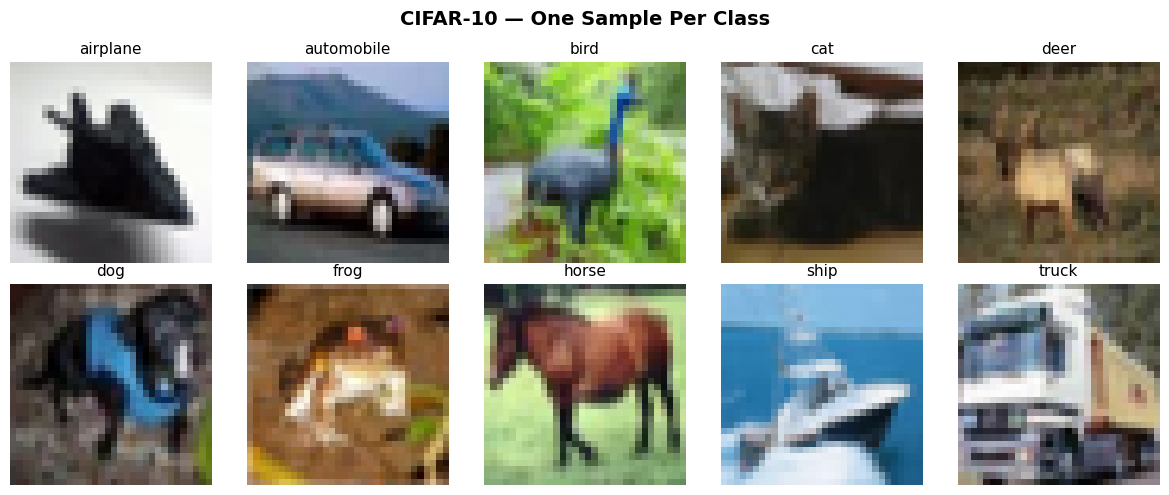

Saved: exploration_class_samples.png


In [23]:
# Denormalize the images for visualization
def denorm(tensor):
    return tensor * 0.5 + 0.5

fig, axes = plt.subplots(2, 5, figsize=(12, 5))
fig.suptitle('CIFAR-10 — One Sample Per Class', fontsize=14, fontweight='bold')

# Collect one sample from each class
shown = {}
for img, label in train_dataset:
    if label not in shown:
        shown[label] = img
    if len(shown) == 10:
        break

# Display samples for all 10 classes
for idx in range(10):
    ax = axes.flat[idx]
    img = denorm(shown[idx]).permute(1, 2, 0).numpy()
    img = np.clip(img, 0, 1)
    ax.imshow(img)
    ax.set_title(CLASS_NAMES[idx], fontsize=11)
    ax.axis('off')

plt.tight_layout()
plt.savefig('exploration_class_samples.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: exploration_class_samples.png')

In [24]:
## 3. Model Architecture & Training

In [25]:
# Define Autoencoder + Classifier
class AutoencoderClassifier(nn.Module):
    def __init__(self):
        super(AutoencoderClassifier, self).__init__()
        # Encoder
        self.enc1 = nn.Conv2d(3, 32, kernel_size=4, stride=2, padding=1)
        self.enc2 = nn.Conv2d(32, 64, kernel_size=4, stride=2, padding=1)
        self.enc3 = nn.Conv2d(64, 128, kernel_size=4, stride=2, padding=1)
        
        # Classification head
        self.fc1 = nn.Linear(128 * 4 * 4, 256)
        self.fc2 = nn.Linear(256, 10)  # 10 CIFAR-10 classes
        self.dropout = nn.Dropout(0.5)
        
    def forward(self, x):
        x = torch.relu(self.enc1(x))
        x = torch.relu(self.enc2(x))
        x = torch.relu(self.enc3(x))
        x = x.view(x.size(0), -1)
        x = torch.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.fc2(x)
        return x

# Initialize model
model = AutoencoderClassifier().to(DEVICE)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

print(f"Model initialized on {DEVICE}")

Model initialized on mps


In [26]:
# Training loop (run for a few epochs)
def train_epoch(model, train_loader, criterion, optimizer, device):
    model.train()
    total_loss = 0.0
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        total_loss += loss.item()
    
    return total_loss / len(train_loader)

# Train for 5 epochs (adjust as needed)
print("Training model...")
for epoch in range(5):
    loss = train_epoch(model, train_loader, criterion, optimizer, DEVICE)
    print(f"Epoch {epoch+1}/5 - Loss: {loss:.4f}")

print("Training complete!")

Training model...
Epoch 1/5 - Loss: 1.6070
Epoch 2/5 - Loss: 1.2629
Epoch 3/5 - Loss: 1.0918
Epoch 4/5 - Loss: 0.9723
Epoch 5/5 - Loss: 0.8570
Training complete!


## 4. Kaggle Submission

The code above generates `submission.csv` with predictions for all 300,000 test images in the format:

```
id,label
1,cat
2,truck
3,bird
...
300000,airplane
```

### How to Submit to Kaggle:

1. **File is ready**: `submission.csv` is generated and saved in your workspace
2. **Download the file** from your workspace
3. **Go to Kaggle competition page**
4. **Click "Submit predictions"** button
5. **Upload `submission.csv`** and submit

Your submission will be automatically scored against the test set!

In [28]:
NUM_BINS = 50
PIXEL_RANGE = (0, 1)   # change to (0,255) if denorm returns uint8-like values

channel_names = ['Red', 'Green', 'Blue']
channel_colors = ['red', 'green', 'blue']

# Accumulate histograms here
histograms = [
    torch.zeros(NUM_BINS),
    torch.zeros(NUM_BINS),
    torch.zeros(NUM_BINS)
]

total_pixels = [0, 0, 0]

# Iterate through ALL batches
for batch_imgs, _ in train_loader:

    # Undo normalization
    batch_imgs = denorm(batch_imgs)

    # Move to CPU once if needed
    batch_imgs = batch_imgs.cpu()

    # Process each channel
    for c in range(3):

        channel_data = batch_imgs[:, c, :, :].reshape(-1)

        # Compute histogram directly with torch
        hist = torch.histc(
            channel_data,
            bins=NUM_BINS,
            min=PIXEL_RANGE[0],
            max=PIXEL_RANGE[1]
        )

        histograms[c] += hist
        total_pixels[c] += channel_data.numel()

# Plotting
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
fig.suptitle(
    'Pixel Value Distribution per Channel (Full Dataset)',
    fontsize=13,
    fontweight='bold'
)

bin_edges = torch.linspace(
    PIXEL_RANGE[0],
    PIXEL_RANGE[1],
    NUM_BINS + 1
)

for c in range(3):

    centers = (bin_edges[:-1] + bin_edges[1:]) / 2

    axes[c].bar(
        centers.numpy(),
        histograms[c].numpy(),
        width=(PIXEL_RANGE[1] - PIXEL_RANGE[0]) / NUM_BINS,
        color=channel_colors[c],
        alpha=0.7,
        edgecolor='black',
        linewidth=0.3
    )

    axes[c].set_title(f'{channel_names[c]} channel')
    axes[c].set_xlabel('Pixel value')
    axes[c].set_ylabel('Count')

plt.tight_layout()

plt.savefig(
    'exploration_pixel_distribution_full_dataset.png',
    dpi=150,
    bbox_inches='tight'
)

plt.show()

print('Saved: exploration_pixel_distribution_full_dataset.png')


# Was taking a lot of time so i skipped this part, but here is the code for t-SNE visualization of latent space:

KeyboardInterrupt: 

In [ ]:
# mean image per class
class_sums   = {i: torch.zeros(3, 32, 32) for i in range(10)}
class_counts = {i: 0 for i in range(10)}

for img, label in train_dataset:
    class_sums[label]   += denorm(img)
    class_counts[label] += 1

fig, axes = plt.subplots(2, 5, figsize=(12, 5))
fig.suptitle('Mean Image Per Class', fontsize=14, fontweight='bold')

for idx, ax in enumerate(axes.flat):
    mean_img = (class_sums[idx] / class_counts[idx]).permute(1, 2, 0).numpy()
    mean_img = np.clip(mean_img, 0, 1)
    ax.imshow(mean_img)
    ax.set_title(CLASS_NAMES[idx])
    ax.axis('off')

plt.tight_layout()
plt.savefig('exploration_mean_images.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: exploration_mean_images.png')

# Convolutional AutoEncoder Architecture

In [29]:
class Encoder(nn.Module):
    def __init__(self, latent_dim=128):
        super().__init__()
        self.net = nn.Sequential(
             # 3 x 32 x 32  ->  32 x 16 x 16
            nn.Conv2d(3, 32, kernel_size=3, stride=2, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            # 32 x 16 x 16  ->  64 x 8 x 8
            nn.Conv2d(32, 64, kernel_size=3, stride=2, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            # 64 x 8 x 8  ->  128 x 4 x 4
            nn.Conv2d(64, 128, kernel_size=3, stride=2, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.Flatten(),
            nn.Linear(128 * 4 * 4, latent_dim),
        )
    def forward(self, x):
        return self.net(x)


class Decoder(nn.Module):
    def __init__(self, latent_dim=128):
        super().__init__()
        self.fc = nn.Linear(latent_dim, 128 * 4 * 4)
        self.net = nn.Sequential(
            # 128 x 4 x 4  ->  64 x 8 x 8
            nn.ConvTranspose2d(128, 64, kernel_size=3, stride=2, padding=1, output_padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            # 64 x 8 x 8  ->  32 x 16 x 16
            nn.ConvTranspose2d(64, 32, kernel_size=3, stride=2, padding=1, output_padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            # 32 x 16 x 16  ->  3 x 32 x 32
            nn.ConvTranspose2d(32, 3, kernel_size=3, stride=2, padding=1, output_padding=1),
            nn.Tanh(),   # output in [-1, 1] to match our normalization
        )
    def forward(self, z):
        x = self.fc(z).view(-1, 128, 4, 4)
        return self.net(x)


class Autoencoder(nn.Module):
    def __init__(self, latent_dim=128):
        super().__init__()
        self.encoder = Encoder(latent_dim)
        self.decoder = Decoder(latent_dim)
    def forward(self, x):
        z = self.encoder(x)
        return self.decoder(z)


LATENT_DIM = 128
model = Autoencoder(latent_dim=LATENT_DIM).to(DEVICE)

total_params = sum(p.numel() for p in model.parameters())
print(f'Total parameters: {total_params:,}')

print(model)

Total parameters: 713,475
Autoencoder(
  (encoder): Encoder(
    (net): Sequential(
      (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
      (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (2): ReLU()
      (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
      (4): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (5): ReLU()
      (6): Conv2d(64, 128, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
      (7): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (8): ReLU()
      (9): Flatten(start_dim=1, end_dim=-1)
      (10): Linear(in_features=2048, out_features=128, bias=True)
    )
  )
  (decoder): Decoder(
    (fc): Linear(in_features=128, out_features=2048, bias=True)
    (net): Sequential(
      (0): ConvTranspose2d(128, 64, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), output_p

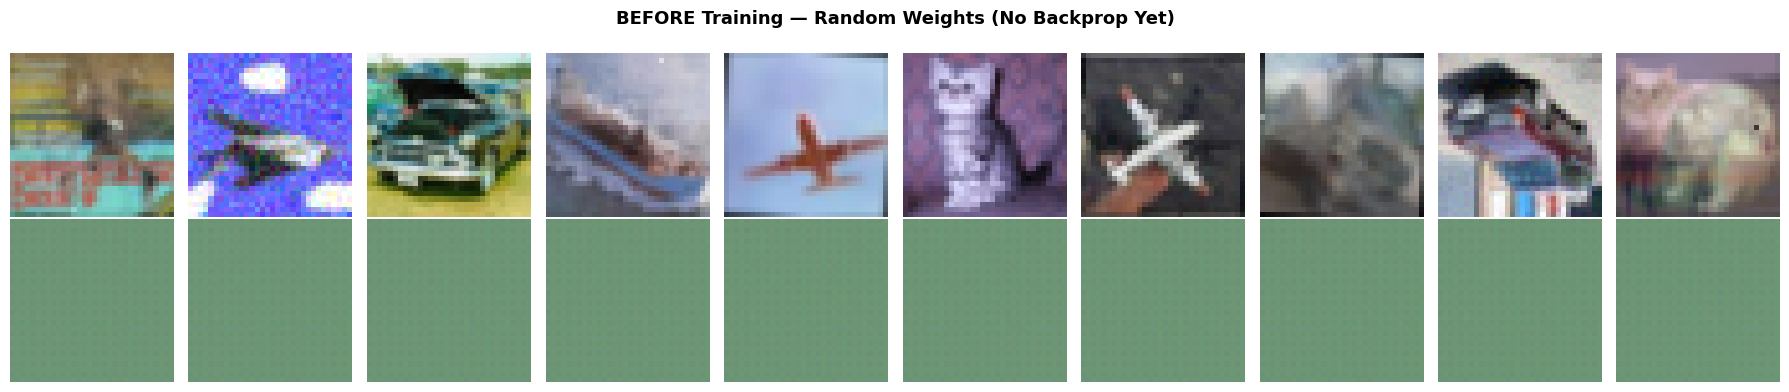

Saved: before_training.png


In [30]:
# grabbing a fixed batch for visualization before training
fixed_batch, fixed_labels = next(iter(test_loader))
fixed_batch = fixed_batch[:10].to(DEVICE)

model.eval()
with torch.no_grad():
    recon_before = model(fixed_batch).cpu()

def show_comparison(originals, reconstructions, title, filename):
    n = len(originals)
    fig, axes = plt.subplots(2, n, figsize=(n * 1.8, 4))
    fig.suptitle(title, fontsize=13, fontweight='bold')
    axes[0, 0].set_ylabel('Original',      fontsize=10)
    axes[1, 0].set_ylabel('Reconstructed', fontsize=10)
    for i in range(n):
        orig = np.clip(denorm(originals[i]).permute(1,2,0).numpy(), 0, 1)
        rec  = np.clip(denorm(reconstructions[i]).permute(1,2,0).numpy(), 0, 1)
        axes[0, i].imshow(orig);  axes[0, i].axis('off')
        axes[1, i].imshow(rec);   axes[1, i].axis('off')
    plt.tight_layout()
    plt.savefig(filename, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'Saved: {filename}')

show_comparison(
    fixed_batch.cpu(), recon_before,
    'BEFORE Training — Random Weights (No Backprop Yet)',
    'before_training.png'
)

In [31]:
EPOCHS    = 60
LR        = 1e-3

criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=LR)
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=10, gamma=0.5)

train_losses = []
test_losses  = []

for epoch in range(1, EPOCHS + 1):
    # ── Train ────────────────────────────────────────────────────────────────
    model.train()
    running_loss = 0.0
    for imgs, _ in train_loader:
        imgs = imgs.to(DEVICE)
        optimizer.zero_grad()
        output = model(imgs)
        loss   = criterion(output, imgs)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * imgs.size(0)

    train_loss = running_loss / len(train_dataset)
    train_losses.append(train_loss)

    # ── Evaluate ─────────────────────────────────────────────────────────────
    model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for imgs, _ in test_loader:
            imgs = imgs.to(DEVICE)
            val_loss += criterion(model(imgs), imgs).item() * imgs.size(0)
    test_loss = val_loss / len(test_dataset)
    test_losses.append(test_loss)

    scheduler.step()

    if epoch % 5 == 0 or epoch == 1:
        print(f'Epoch [{epoch:2d}/{EPOCHS}]  Train Loss: {train_loss:.5f}  Test Loss: {test_loss:.5f}')

print('\nTraining complete!')

Epoch [ 1/60]  Train Loss: 0.06905  Test Loss: 0.03136
Epoch [ 5/60]  Train Loss: 0.02187  Test Loss: 0.01808
Epoch [10/60]  Train Loss: 0.02028  Test Loss: 0.01685
Epoch [15/60]  Train Loss: 0.01933  Test Loss: 0.01600
Epoch [20/60]  Train Loss: 0.01908  Test Loss: 0.01659
Epoch [25/60]  Train Loss: 0.01858  Test Loss: 0.01570
Epoch [30/60]  Train Loss: 0.01850  Test Loss: 0.01560
Epoch [35/60]  Train Loss: 0.01831  Test Loss: 0.01558
Epoch [40/60]  Train Loss: 0.01826  Test Loss: 0.01552
Epoch [45/60]  Train Loss: 0.01817  Test Loss: 0.01545
Epoch [50/60]  Train Loss: 0.01814  Test Loss: 0.01545
Epoch [55/60]  Train Loss: 0.01809  Test Loss: 0.01543
Epoch [60/60]  Train Loss: 0.01807  Test Loss: 0.01541

Training complete!


In [32]:
# Generate predictions for all test images
print("Generating predictions for test set...")

# Get all test image IDs
test_image_files = sorted([f for f in os.listdir('test') if f.endswith('.png')])
test_ids = [int(f.replace('.png', '')) for f in test_image_files]

print(f"Found {len(test_ids)} test images")

# Create test dataset without labels
class TestDataset(Dataset):
    def __init__(self, img_dir, image_ids, transform=None):
        self.img_dir = img_dir
        self.image_ids = image_ids
        self.transform = transform
    
    def __len__(self):
        return len(self.image_ids)
    
    def __getitem__(self, idx):
        img_id = self.image_ids[idx]
        img_path = os.path.join(self.img_dir, f'{img_id}.png')
        img = Image.open(img_path).convert('RGB')
        
        if self.transform:
            img = self.transform(img)
        
        return img, img_id

# Create test loader
test_dataset_pred = TestDataset('test', test_ids, transform=transform)
test_loader_pred = DataLoader(test_dataset_pred, batch_size=128, shuffle=False, num_workers=2)

# Generate predictions
model.eval()
all_predictions = []
all_ids = []

with torch.no_grad():
    for images, img_ids in test_loader_pred:
        images = images.to(DEVICE)
        outputs = model(images)
        preds = torch.argmax(outputs, dim=1).cpu().numpy()
        
        all_predictions.extend(preds)
        all_ids.extend(img_ids.cpu().numpy())

# Create submission dataframe matching sampleSubmission.csv format
submission_df = pd.DataFrame({
    'id': all_ids,
    'label': [CLASS_NAMES[int(pred)] for pred in all_predictions]
})

# Save to CSV
submission_df.to_csv('submission.csv', index=False)
print(f"\n✓ Saved: submission.csv")
print(f"Total predictions: {len(submission_df)}")
print(f"\nFirst 10 rows:")
print(submission_df.head(10))
print(f"\nLast 10 rows:")
print(submission_df.tail(10))

Generating predictions for test set...
Found 300000 test images


Traceback (most recent call last):
  File "<string>", line 1, in <module>
  File "/Users/mclight/Downloads/GitHub/AI_Self-Study/.conda/lib/python3.11/multiprocessing/spawn.py", line 122, in spawn_main
    exitcode = _main(fd, parent_sentinel)
               ^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/Users/mclight/Downloads/GitHub/AI_Self-Study/.conda/lib/python3.11/multiprocessing/spawn.py", line 132, in _main
    self = reduction.pickle.load(from_parent)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
AttributeError: Can't get attribute 'TestDataset' on <module '__main__' (built-in)>


KeyboardInterrupt: 

Saved: loss_curves.png


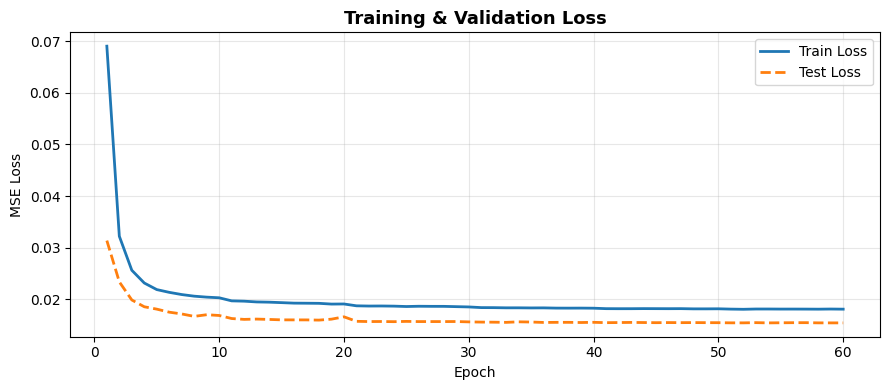

In [33]:
# loss curves
fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(range(1, EPOCHS+1), train_losses, label='Train Loss', linewidth=2)
ax.plot(range(1, EPOCHS+1), test_losses,  label='Test Loss',  linewidth=2, linestyle='--')
ax.set_xlabel('Epoch')
ax.set_ylabel('MSE Loss')
ax.set_title('Training & Validation Loss', fontsize=13, fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('loss_curves.png', dpi=150, bbox_inches='tight')
print('Saved: loss_curves.png')

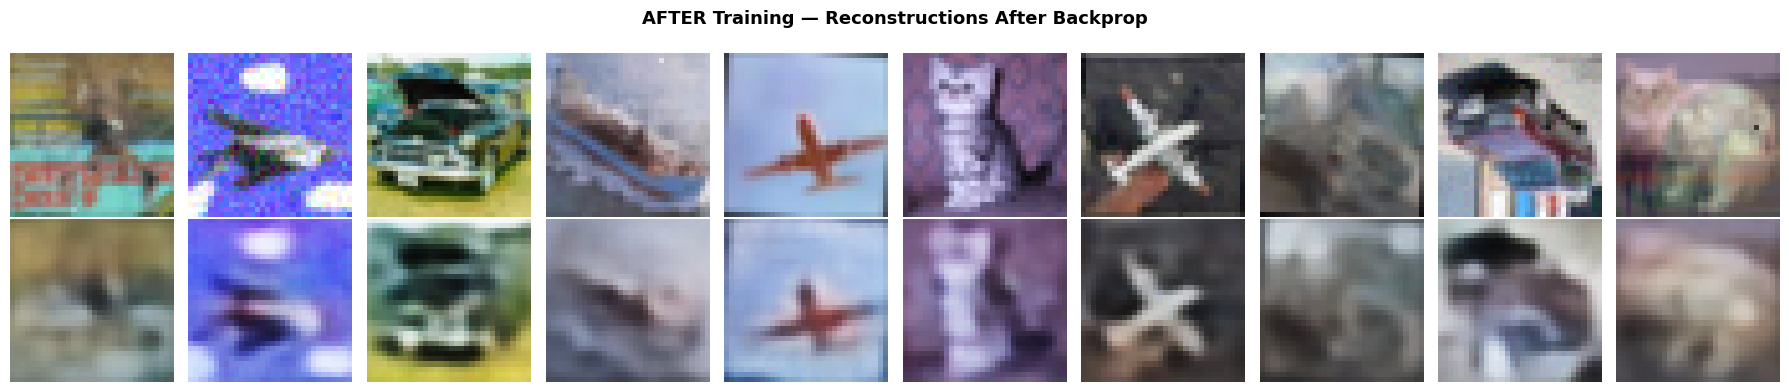

Saved: after_training.png


In [34]:
# after training - before vs after backprop comparison
model.eval()
with torch.no_grad():
    recon_after = model(fixed_batch).cpu()

show_comparison(
    fixed_batch.cpu(), recon_after,
    'AFTER Training — Reconstructions After Backprop',
    'after_training.png'
)

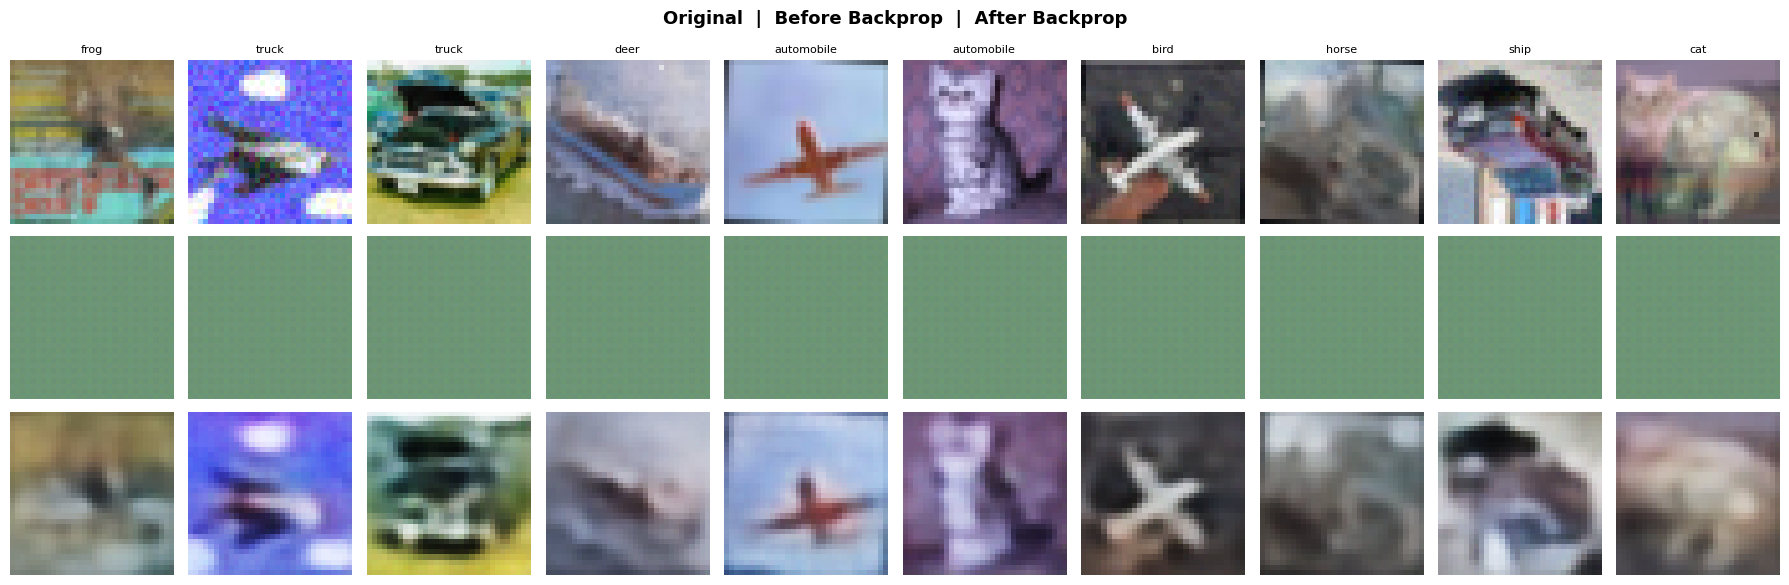

Saved: before_vs_after_backprop.png


In [35]:
# Original | Before | After
n = 10
fig, axes = plt.subplots(3, n, figsize=(n * 1.8, 6))
fig.suptitle('Original  |  Before Backprop  |  After Backprop', fontsize=13, fontweight='bold')

row_labels = ['Original', 'Before\nBackprop', 'After\nBackprop']
rows_data  = [fixed_batch.cpu(), recon_before, recon_after]

for row, (label, data) in enumerate(zip(row_labels, rows_data)):
    axes[row, 0].set_ylabel(label, fontsize=10, rotation=0, labelpad=50, va='center')
    for col in range(n):
        img = np.clip(denorm(data[col]).permute(1,2,0).numpy(), 0, 1)
        axes[row, col].imshow(img)
        axes[row, col].axis('off')
        if row == 0:
            axes[row, col].set_title(CLASS_NAMES[fixed_labels[col].item()], fontsize=8)

plt.tight_layout()
plt.savefig('before_vs_after_backprop.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: before_vs_after_backprop.png')

In [36]:
# reconstruction error per class
model.eval()
class_losses  = {i: [] for i in range(10)}
mse_per_pixel = nn.MSELoss(reduction='none')

with torch.no_grad():
    for imgs, labels in test_loader:
        imgs   = imgs.to(DEVICE)
        recons = model(imgs)
        losses = mse_per_pixel(recons, imgs).mean(dim=[1,2,3]).cpu().numpy()
        for loss_val, label in zip(losses, labels.numpy()):
            class_losses[label].append(loss_val)

means = [np.mean(class_losses[i]) for i in range(10)]
stds  = [np.std(class_losses[i])  for i in range(10)]

fig, ax = plt.subplots(figsize=(11, 4))
bars = ax.bar(CLASS_NAMES, means, yerr=stds, capsize=4,
              color=plt.cm.tab10(np.linspace(0,1,10)), alpha=0.85, edgecolor='black', linewidth=0.4)
ax.set_title('Reconstruction MSE per Class (Test Set)', fontsize=13, fontweight='bold')
ax.set_ylabel('MSE Loss')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('reconstruction_error_per_class.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: reconstruction_error_per_class.png')

KeyboardInterrupt: 

Running t-SNE... (may take ~30s)


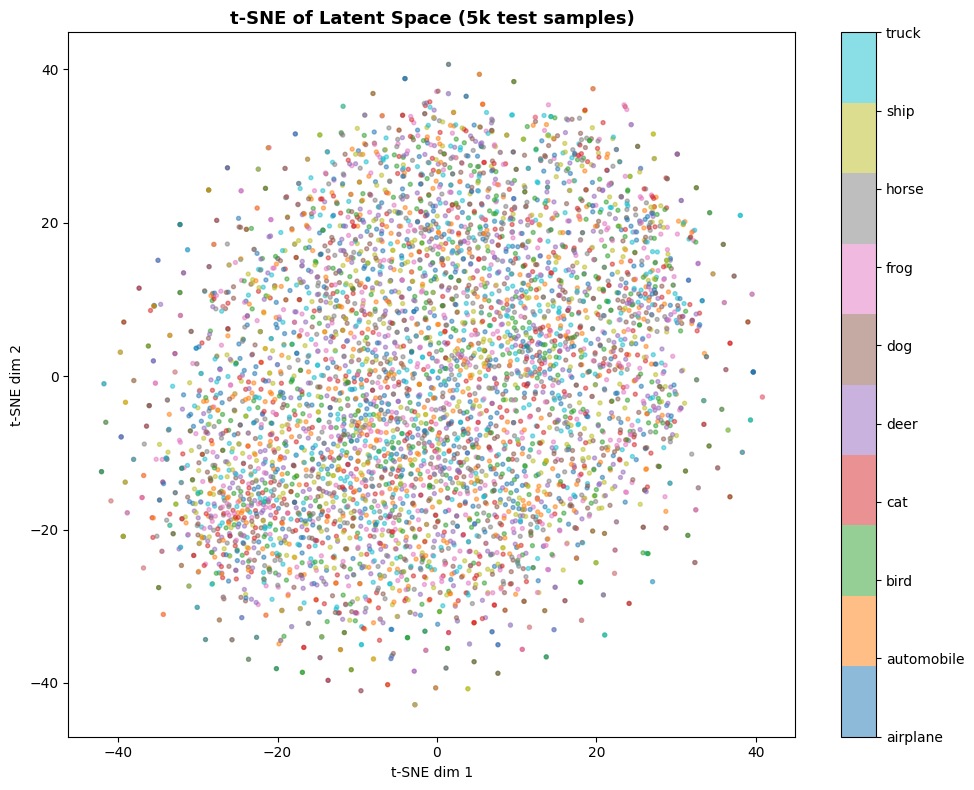

Saved: tsne_latent_space.png


In [17]:
# t-SNE visualization of latent space
from sklearn.manifold import TSNE

model.eval()
all_z, all_labels = [], []

with torch.no_grad():
    for imgs, labels in test_loader:
        z = model.encoder(imgs.to(DEVICE)).cpu().numpy()
        all_z.append(z)
        all_labels.append(labels.numpy())
        if len(all_z) * 128 >= 5000:
            break  # use 5k samples to keep t-SNE fast

all_z      = np.concatenate(all_z)[:5000]
all_labels = np.concatenate(all_labels)[:5000]

print('Running t-SNE... (may take ~30s)')
tsne   = TSNE(n_components=2, random_state=42, perplexity=40, max_iter=1000)
z_2d   = tsne.fit_transform(all_z)

fig, ax = plt.subplots(figsize=(10, 8))
scatter = ax.scatter(z_2d[:, 0], z_2d[:, 1],
                     c=all_labels, cmap='tab10', alpha=0.5, s=8)
cbar = plt.colorbar(scatter, ax=ax, ticks=range(10))
cbar.set_ticklabels(CLASS_NAMES)
ax.set_title('t-SNE of Latent Space (5k test samples)', fontsize=13, fontweight='bold')
ax.set_xlabel('t-SNE dim 1')
ax.set_ylabel('t-SNE dim 2')
plt.tight_layout()
plt.savefig('tsne_latent_space.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: tsne_latent_space.png')

In [18]:
torch.save(model.state_dict(), 'cifar10_autoencoder.pth')
print('Model saved to cifar10_autoencoder.pth')

Model saved to cifar10_autoencoder.pth
